In [46]:
using Plots
using Revise
using DataInterpolations
using RegularizationTools

In [47]:
function read_custom_file(filepath::String)
    array1 = Float64[]
    array2 = Float64[]
    
    start_reading = false
    
    num_regex = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"

    open(filepath, "r") do file
        for line in eachline(file)

            clean_line = strip(line)

            if startswith(clean_line, "+") || startswith(clean_line, "-")
                matches = [m.match for m in eachmatch(num_regex, clean_line)]

                if length(matches) >= 2
                    push!(array1, parse(Float64, matches[1]))
                    push!(array2, parse(Float64, matches[2]))
                end
            else
                continue
            end
        end
    end
    return array1, array2
end

read_custom_file (generic function with 1 method)

In [48]:
H_read = Float64[]
M_read = Float64[]
H_read, M_read = read_custom_file("/home/lali/TITAN-ROG-sync/julia/_Magnetism/S9281/S9281-FORC-100-2000-5s.txt")

([1964.88, 1985.336, 2004.983, 1925.77, 1964.717, 2004.902, 1885.575, 1925.586, 1965.699, 2004.905  …  1644.077, 1683.239, 1723.389, 1763.509, 1803.628, 1843.818, 1884.059, 1924.176, 1964.332, 2004.483], [0.0002258643, 0.0002262753, 0.0002263724, 0.000225742, 0.0002259357, 0.0002263749, 0.0002245896, 0.0002248335, 0.0002261193, 0.0002258196  …  0.0002120756, 0.0002126918, 0.0002129096, 0.0002124456, 0.0002130614, 0.000215013, 0.0002162812, 0.0002172486, 0.0002173355, 0.0002163766])

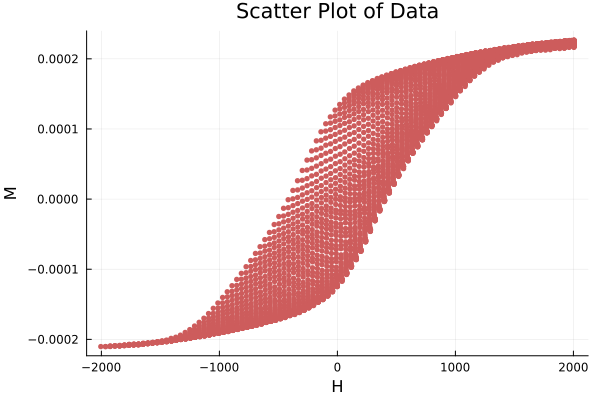

In [49]:
scatter(H_read, M_read, 
    title = "Scatter Plot of Data", 
    xlabel = "H", 
    ylabel = "M", 
    legend = false,   
    markersize = 3, 
    markercolor = :indianred,
    markerstrokecolor =:indianred
)

In [50]:
# Detect FORCs (Hr, numPointsPerFORC)
Hr_read = Float64[]
numPointsPerFORC = Int[]

current_Hr = H_read[1]
push!(Hr_read, current_Hr)

counterPointsPerFORC = 1

for i in 2:(length(H_read))
    if H_read[i] < H_read[i-1]
        global current_Hr = H_read[i]
        push!(numPointsPerFORC, counterPointsPerFORC)
        global counterPointsPerFORC = 0
    end
    global counterPointsPerFORC += 1
    push!(Hr_read, current_Hr)
end
push!(numPointsPerFORC, counterPointsPerFORC)
numFORCs = length(numPointsPerFORC)

println("----------- Total $(length(numPointsPerFORC)) FORCs -----------")
println("---------  $(numPointsPerFORC[1]) first / $(numPointsPerFORC[numFORCs]) last ---------")

----------- Total 101 FORCs -----------
---------  3 first / 101 last ---------


In [51]:
# Save Hr-H-M original file
n = length(Hr_read)
if length(H_read) != n || length(M_read) != n
    error("Error: All three arrays must have the same length.")
end

open("/home/lali/TITAN-ROG-sync/julia/_Magnetism/S9281/S9281-FORC-100-2000-5s_Hr-H-M_orig.dat", "w") do file
    for i in 1:n
        println(file, "$(Hr_read[i]), $(H_read[i]), $(M_read[i])")
    end
end

In [52]:
function gimmeOneFORC(theFORC::Int64)
    contorNumPoints = 0
    H_interp = Float64[]
    M_interp = Float64[]
    #detect indexes for $(theFORC)
    for i in 1:theFORC-1
        contorNumPoints += numPointsPerFORC[i]
    end

    myHr = Hr_read[contorNumPoints]
    startPointOnFORC = contorNumPoints + 1
    push!(H_interp, H_read[startPointOnFORC])
    push!(M_interp, M_read[startPointOnFORC])
    contorNumPoints = 1
    while (Hr_read[startPointOnFORC+contorNumPoints-1] - Hr_read[startPointOnFORC+contorNumPoints]) < 1.0e-5 #eps - compare floats
        push!(H_interp, H_read[startPointOnFORC+contorNumPoints])
        push!(M_interp, M_read[startPointOnFORC+contorNumPoints])
        contorNumPoints += 1
    end
    H_interp, M_interp
end

gimmeOneFORC (generic function with 1 method)

In [53]:
showTest = false

false

In [54]:
if (showTest)
    plotInterpFORC = div(numFORCs * 2, 3)
    println("----------------- Interpolating  $(plotInterpFORC)-th FORC ----------------")
    H_interp, M_interp = gimmeOneFORC(plotInterpFORC)
    Example = AkimaInterpolation(M_interp, H_interp)
    plot(Example)
end

In [55]:
if (showTest)
    t, u = gimmeOneFORC(plotInterpFORC)
    d = 2
    A = RegularizationSmooth(u, t, d; alg=:gcv_svd)
    û = A.û
    N = 200
    titp = collect(range(minimum(t), maximum(t), length=N))
    uitp = A.(titp)
    #Am = RegularizationSmooth(u, t, titp, d; alg=:gcv_svd)
    #ûm = Am.û
    scatter(t, u, label="simulated data", legend=:top)
    plot!(titp, uitp, label="smoothed interpolation")
end